#### Problem Statement
#### Monitor Urban Traffic 
#### Detecting Congention and incidents early
#### Support emergemcy response and traffic control decisions



#### Current Problems Faced 
#### Manual Traffic is low and inefficent
#### CCTV and aerial footage are not analysed intelligently
#### Congentions are detected too late
#### No data driven visuslisation to support quick decsions


#### Core Need
#### Analyze aerial imagery–derived traffic data
#### Automatically detect congestion or incidents
#### Provide visual risk maps for decision-makers

#### Step 0
#### Tools Used
#### Python 3.14.2
#### Jupyter Notebook
#### Libraries Used
#### pandas 
#### numpy 
#### matplotlib 
#### seaborn
#### scikit-learn




#### Step2 Load the dataset

In [5]:
import numpy as np
import pandas as pd
df = pd.read_csv("D:\\data E\\New Volume\\Python programming tutorials\\TIhan-IIT-MASAI\\Traffic Congestion - Sheet1.csv")
df

,vehicle_density,avg_vehicle_speed,speed_std,lane_occupancy,queue_length,edge_density,optical_flow_mag,shadow_fraction,time_of_day_norm,road_width_norm,label
0,23.865083,56.660004,5.737366,0.448821,13.583201,0.412864,0.395673,0.127440,0.334763,0.990240,1
1,15.755624,67.562554,3.761696,0.203759,9.119581,0.343221,0.877234,0.197382,0.688851,0.663392,0
2,14.719641,60.782993,3.558324,0.259485,6.966499,0.336209,0.455082,0.196271,0.279968,0.905470,0
3,14.719814,72.431960,0.560680,0.210146,4.188474,0.277365,0.730398,0.090561,0.643183,0.891052,0
4,43.372854,33.125925,12.071894,0.685767,9.363837,0.643574,0.210252,0.140736,0.957246,0.944823,1
...,...,...,...,...,...,...,...,...,...,...,...
3995,33.904612,33.008744,4.942720,0.561437,10.734270,0.517602,0.324472,0.167593,0.350173,0.400978,1
3996,1.976232,69.165028,5.933275,0.000000,0.803189,0.247818,0.837066,0.039089,0.594906,0.621571,0
3997,17.191899,60.057134,4.237507,0.282225,8.040950,0.480964,0.698505,0.000000,0.885772,0.440655,0
3998,7.201799,75.401197,6.627375,0.045018,3.679540,0.256966,0.545140,0.102727,0.790446,0.868358,0


In [3]:
df.head() #first five rows 

,vehicle_density,avg_vehicle_speed,speed_std,lane_occupancy,queue_length,edge_density,optical_flow_mag,shadow_fraction,time_of_day_norm,road_width_norm,label
0,23.865083,56.660004,5.737366,0.448821,13.583201,0.412864,0.395673,0.127440,0.334763,0.990240,1
1,15.755624,67.562554,3.761696,0.203759,9.119581,0.343221,0.877234,0.197382,0.688851,0.663392,0
2,14.719641,60.782993,3.558324,0.259485,6.966499,0.336209,0.455082,0.196271,0.279968,0.905470,0
3,14.719814,72.431960,0.560680,0.210146,4.188474,0.277365,0.730398,0.090561,0.643183,0.891052,0
4,43.372854,33.125925,12.071894,0.685767,9.363837,0.643574,0.210252,0.140736,0.957246,0.944823,1


#### Step 2.1 Inspect Data Set


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vehicle_density    4000 non-null   float64
 1   avg_vehicle_speed  4000 non-null   float64
 2   speed_std          4000 non-null   float64
 3   lane_occupancy     4000 non-null   float64
 4   queue_length       4000 non-null   float64
 5   edge_density       4000 non-null   float64
 6   optical_flow_mag   4000 non-null   float64
 7   shadow_fraction    4000 non-null   float64
 8   time_of_day_norm   4000 non-null   float64
 9   road_width_norm    4000 non-null   float64
 10  label              4000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 343.9 KB


In [5]:
df.describe()

,vehicle_density,avg_vehicle_speed,speed_std,lane_occupancy,queue_length,edge_density,optical_flow_mag,shadow_fraction,time_of_day_norm,road_width_norm,label
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,20.116392,55.895658,6.351934,0.335010,7.959204,0.401409,0.560445,0.150426,0.497673,0.699993,0.450000
std,12.604460,16.584939,4.384556,0.209370,5.666685,0.135858,0.182694,0.078367,0.289784,0.172762,0.497556
min,0.326223,5.000000,0.002577,0.000000,0.109818,0.124681,0.000000,0.000000,0.000094,0.400063,0.000000
25%,10.933062,46.412276,2.939375,0.181017,3.922624,0.303003,0.453835,0.094160,0.241122,0.549426,0.000000
50%,17.535134,57.994579,5.780743,0.297576,6.521932,0.378663,0.576044,0.148212,0.495915,0.701816,0.000000
75%,26.604050,67.643562,8.810003,0.453174,10.463889,0.475957,0.691486,0.202875,0.752959,0.845197,1.000000
max,116.858197,90.000000,37.937951,1.000000,43.285818,1.000000,1.000000,0.493909,0.999957,0.999905,1.000000


#### vehicle_density     -----> vehicles per tile      ------> high density : jam
#### avg_vehicle_speed   -----> Mean vehicle speed     ------> Low Speed    : congestion
#### lane_occupancy      -----> % lane used            ------> indicates saturation
#### queue_length        -----> stopped vehicle line   ------> incident indicator
#### optical_flow        -----> Motion Magnitude       ------> low motion = blockage
#### edge_denisty        -----> Structural clutter     ------> COngested paterns
#### time_of_day         -----> Normalized time        ------> Congested patterns
#### 



#### Step 2.2 Cleaning The Data

In [6]:
#1.Handling missing values
df.isnull().sum()

vehicle_density      0
avg_vehicle_speed    0
speed_std            0
lane_occupancy       0
queue_length         0
edge_density         0
optical_flow_mag     0
shadow_fraction      0
time_of_day_norm     0
road_width_norm      0
label                0
dtype: int64

In [7]:
df.dropna()

,vehicle_density,avg_vehicle_speed,speed_std,lane_occupancy,queue_length,edge_density,optical_flow_mag,shadow_fraction,time_of_day_norm,road_width_norm,label
0,23.865083,56.660004,5.737366,0.448821,13.583201,0.412864,0.395673,0.127440,0.334763,0.990240,1
1,15.755624,67.562554,3.761696,0.203759,9.119581,0.343221,0.877234,0.197382,0.688851,0.663392,0
2,14.719641,60.782993,3.558324,0.259485,6.966499,0.336209,0.455082,0.196271,0.279968,0.905470,0
3,14.719814,72.431960,0.560680,0.210146,4.188474,0.277365,0.730398,0.090561,0.643183,0.891052,0
4,43.372854,33.125925,12.071894,0.685767,9.363837,0.643574,0.210252,0.140736,0.957246,0.944823,1
...,...,...,...,...,...,...,...,...,...,...,...
3995,33.904612,33.008744,4.942720,0.561437,10.734270,0.517602,0.324472,0.167593,0.350173,0.400978,1
3996,1.976232,69.165028,5.933275,0.000000,0.803189,0.247818,0.837066,0.039089,0.594906,0.621571,0
3997,17.191899,60.057134,4.237507,0.282225,8.040950,0.480964,0.698505,0.000000,0.885772,0.440655,0
3998,7.201799,75.401197,6.627375,0.045018,3.679540,0.256966,0.545140,0.102727,0.790446,0.868358,0


In [8]:
#2.Removing the duplicates
df.drop_duplicates()

,vehicle_density,avg_vehicle_speed,speed_std,lane_occupancy,queue_length,edge_density,optical_flow_mag,shadow_fraction,time_of_day_norm,road_width_norm,label
0,23.865083,56.660004,5.737366,0.448821,13.583201,0.412864,0.395673,0.127440,0.334763,0.990240,1
1,15.755624,67.562554,3.761696,0.203759,9.119581,0.343221,0.877234,0.197382,0.688851,0.663392,0
2,14.719641,60.782993,3.558324,0.259485,6.966499,0.336209,0.455082,0.196271,0.279968,0.905470,0
3,14.719814,72.431960,0.560680,0.210146,4.188474,0.277365,0.730398,0.090561,0.643183,0.891052,0
4,43.372854,33.125925,12.071894,0.685767,9.363837,0.643574,0.210252,0.140736,0.957246,0.944823,1
...,...,...,...,...,...,...,...,...,...,...,...
3995,33.904612,33.008744,4.942720,0.561437,10.734270,0.517602,0.324472,0.167593,0.350173,0.400978,1
3996,1.976232,69.165028,5.933275,0.000000,0.803189,0.247818,0.837066,0.039089,0.594906,0.621571,0
3997,17.191899,60.057134,4.237507,0.282225,8.040950,0.480964,0.698505,0.000000,0.885772,0.440655,0
3998,7.201799,75.401197,6.627375,0.045018,3.679540,0.256966,0.545140,0.102727,0.790446,0.868358,0


In [17]:
#Encoding
from sklearn.preprocessing import LabelEncoder
a = LabelEncoder()
df['label'] =a.fit_transform(df['label'])
df['label'].value_counts()
a.classes_
#df['label'].head()


array([0, 1])

#### Step 3 Exploratory Data Analysis

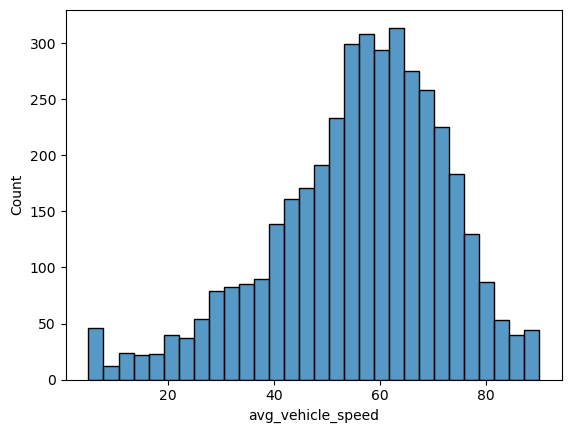

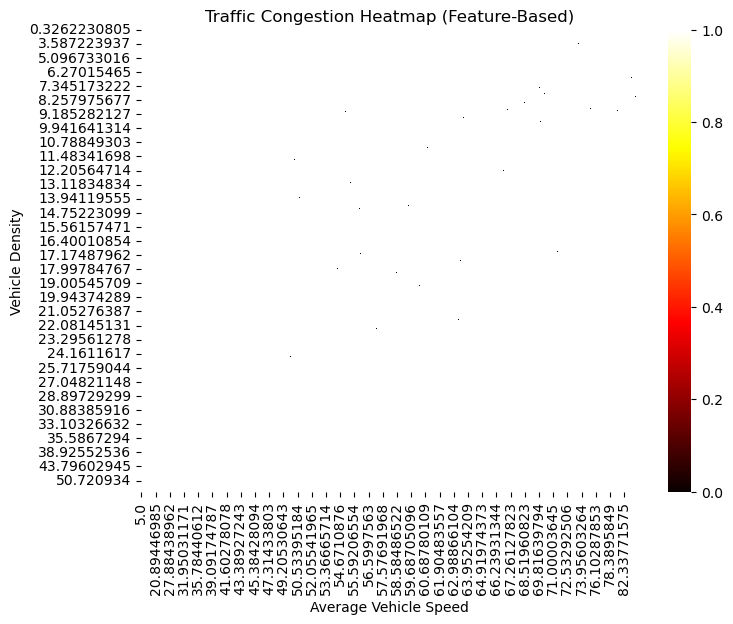

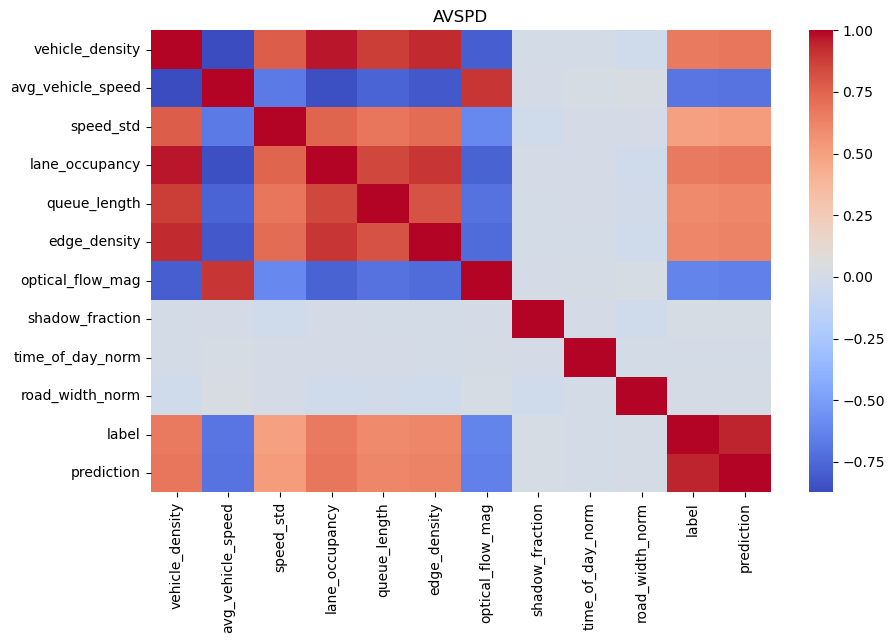

In [23]:
#3.1 Feature DIstribution
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['avg_vehicle_speed'],bins=30)
heatmap_data = pd.pivot_table(
    df,
    values='prediction',
    index='vehicle_density',
    columns='avg_vehicle_speed',
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, cmap='hot')
plt.title("Traffic Congestion Heatmap (Feature-Based)")
plt.xlabel("Average Vehicle Speed")
plt.ylabel("Vehicle Density")
plt.show()

#3.2COrelation analysis
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm',annot=False)
plt.title("AVSPD")
plt.show()

#### STEP 4 Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler
X=df.drop('label',axis=1)
y=df['label']

scaler=StandardScaler()
X_scaled = scaler.fit_transform(X)

#### STEP 5 Train Test Split

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(
    X_scaled,y,test_size=0.2,random_state=42
)

#### STEP 6 ML Model

In [9]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### STep 7 Model Evaluation

In [13]:
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score
y_pred=model.predict(X_test)
y_prob =model.predict_proba(X_test)[:,1]
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print("ROC-AUC:",roc_auc_score(y_test,y_prob))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88       443
           1       0.88      0.79      0.83       357

    accuracy                           0.86       800
   macro avg       0.86      0.85      0.85       800
weighted avg       0.86      0.86      0.86       800

[[403  40]
 [ 75 282]]
ROC-AUC: 0.9325834171140237


#### Step 8 Spatial Aggregation


In [24]:
df['prediction'] = model.predict(X_scaled)

heatmap_data = (
    df.groupby(['tile_x', 'tile_y'])['prediction']
    .mean()
    .unstack()
)

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, cmap='hot')
plt.title("Traffic Congestion Heatmap")
plt.xlabel("Tile Y Coordinate")
plt.ylabel("Tile X Coordinate")
plt.show()


KeyError: 'tile_x'

In [20]:
df.columns

Index(['vehicle_density', 'avg_vehicle_speed', 'speed_std', 'lane_occupancy',
       'queue_length', 'edge_density', 'optical_flow_mag', 'shadow_fraction',
       'time_of_day_norm', 'road_width_norm', 'label', 'prediction'],
      dtype='object')